# LASSO with Cross-Validation

This demonstration notebook builds toward fitting a **LASSO regression model with cross-validation** and asks a trust question throughout: **how much does the validation strategy influence the model and regularization strength we select?**

We begin with the same noisy quartic data used in the fundamentals of machine learning demonstration. The first lesson compares leaked, whole-dataset standardization with fully nested fold-safe preprocessing using paired out-of-fold parity plots.

## Questions to Guide Your Exploration

Use these questions to scaffold your exploration. Revisit them as you change the controls, compare validation strategies, and interpret the resulting fits.

- We use basically the same trick to look at both generalizability and stability: change the cross-validation split, refit the model, and repeat. Why does looking at different outputs from essentially the same experiment allow us to answer two rather different questions about the model?

- In class I was very particular about keeping more than one polynomial after we looked at generalizability. Should we also have kept more than one value of lambda for the later analysis? If it had been you, what model—or set of models—would you have carried forward, and why? What might we be hiding by picking one apparently “good” lambda and sticking with it?

- Are you bothered by the fact that the fitted coefficients do not always agree with the known ground-truth coefficients? Should you be? Do they at least preserve things like sign, relative importance, or general behavior? Do the degree-4 and degree-5 models tell basically the same story? Could you trust the predictions of a model without necessarily trusting its coefficients as a scientific explanation?

- We deliberately looked at one fairly obvious form of information leakage. What other forms of leakage could occur during model development? For each one, think about what information is leaking, where it is leaking to, and which claim about the model would become less trustworthy as a result.

- Before looking at the robustness plots, make a prediction: as input noise increases, what should fall apart first—the predictive performance or our ability to interpret the coefficients? Decide what “fall apart” means before you look. Test your prediction for both the degree-4 and degree-5 models. If they behave differently, why do you think that is? Does your answer depend on whether you use K-fold or LOCO?

- There is quite a bit of scatter in the fitted coefficients, and some sensitivity in the performance metrics to the particular cross-validation split. Yet the prediction envelopes can still be remarkably narrow over parts of the input space. How can the parameters move around while the predictions stay stable? Where does that stability break down? Based on everything you have seen, what would you be comfortable trusting these models to do—and what stronger claim would you not be willing to make?

## 1. Notebook Scaffold

The notebook locates the repository root automatically whether the kernel is launched from the repository root or from `demonstrations/`. All generated artifacts go into the repository-level `artifacts/` directory, which is ignored by Git.

In [33]:
from pathlib import Path

def find_repository_root(start_directory):
    start_directory = Path(start_directory).resolve()
    for candidate in [start_directory, *start_directory.parents]:
        if (candidate / "demonstrations" / "lasso_cv.ipynb").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository containing demonstrations/lasso_cv.ipynb"
    )

REPO_ROOT = find_repository_root(Path.cwd())
ARTIFACT_DIR = REPO_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f"Repository root: {REPO_ROOT}")

Repository root: /Users/jae3goals/Jupyter Code on Root/MSE420 AI Forensics


## 2. Environment Setup and Imports

These dependencies support data generation, visualization, the cross-validation strategies, and the LASSO workflow. Version printouts make the computational environment part of the evidence.

In [34]:
import sys
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from matplotlib.colors import LogNorm
from IPython.display import display
from ipywidgets import BoundedFloatText, BoundedIntText, Dropdown, FloatLogSlider, FloatSlider, HBox, IntSlider, SelectionSlider, VBox, interactive_output
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso, lasso_path
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, LeaveOneGroupOut, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

print({"python": sys.version.split()[0], "numpy": np.__version__, "scikit_learn": sklearn.__version__})

{'python': '3.11.16', 'numpy': '2.4.6', 'scikit_learn': '1.9.1'}


## 3. Ground-Truth Function

The underlying relationship is a quartic $y = ax^4 + bx^3 + cx^2 + dx + e$ chosen so it has exactly one minimum but is asymmetric enough that a second-order polynomial cannot fit it well. The coefficients are verified below rather than assumed.

Ground-truth quartic verified to have 1 minimum over its domain.


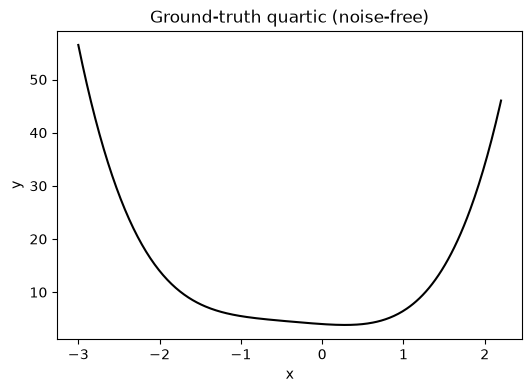

In [35]:
TRUE_COEFFICIENTS = np.array([1.0, 1.5, 1.0, -1.0, 4.0])  # a*x^4 + b*x^3 + c*x^2 + d*x + e
X_RANGE = (-3.0, 2.2)

def true_function(x):
    return np.polyval(TRUE_COEFFICIENTS, x)

def count_minima(coefficients):
    derivative = np.polyder(coefficients)
    second_derivative = np.polyder(derivative)
    roots = np.roots(derivative)
    real_roots = roots[np.isclose(roots.imag, 0.0)].real
    return sum(np.polyval(second_derivative, root) > 0 for root in real_roots)

n_minima = count_minima(TRUE_COEFFICIENTS)
assert n_minima == 1, f"Expected exactly one minimum, found {n_minima}."
print(f"Ground-truth quartic verified to have {n_minima} minimum over its domain.")

x_curve = np.linspace(*X_RANGE, 400)
with plt.ioff():
    ground_truth_figure, ground_truth_ax = plt.subplots(figsize=(6, 4))
ground_truth_ax.plot(x_curve, true_function(x_curve), color="black")
ground_truth_ax.set(title="Ground-truth quartic (noise-free)", xlabel="x", ylabel="y")
display(ground_truth_figure)
plt.close(ground_truth_figure)

## 4. Noisy Data Generation

Samples are drawn uniformly over the domain and evaluated on the true function, then perturbed with Gaussian noise. A fixed data-generation seed controls both the sampled locations and the noise draw. Keeping this seed separate from the cross-validation seed lets us change validation splits without silently changing the dataset.

In [36]:
N_POINTS = 60
DATA_GENERATION_SEED = 2024
NOISE_STD = 1.0

def generate_dataset(noise_std=NOISE_STD, n_points=N_POINTS, x_range=X_RANGE):
    rng = np.random.default_rng(DATA_GENERATION_SEED)
    x = rng.uniform(x_range[0], x_range[1], size=n_points)
    y = true_function(x) + rng.normal(0.0, noise_std, size=n_points)
    order = np.argsort(x)
    return x[order], y[order]

x, y = generate_dataset()
print(f"Generated {len(x)} points | x range: [{x.min():.2f}, {x.max():.2f}]")

Generated 60 points | x range: [-2.98, 2.18]


## 5. Cross-Validation Splitters

We prepare three validation schemes for later LASSO comparisons:

- **K-fold** holds out shuffled groups of points and estimates interpolation performance.
- **Leave-one-out** validates every observation individually and is deterministic.
- **Leave-one-cluster-out** groups nearby `x` values with k-means and holds out one entire region at a time, testing a more demanding form of spatial generalization.

Each scheme is materialized as a reusable list of `(train_indices, validation_indices)` pairs. These are the **outer** folds used to estimate validation performance. When lambda must also be selected, a separate deterministic inner cross-validation is performed within each outer training fold. The CV seed affects K-fold shuffling and k-means initialization, but not the dataset or leave-one-out.

In [37]:
N_SPLITS = 5
CV_SEED = 420

def make_cv_splits(x, n_splits=N_SPLITS, cv_seed=CV_SEED):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)
    leave_one_out = LeaveOneOut()

    cluster_labels = KMeans(
        n_clusters=n_splits,
        random_state=cv_seed,
        n_init=10,
    ).fit_predict(x.reshape(-1, 1))
    leave_one_cluster_out = LeaveOneGroupOut()

    return {
        "k-fold": list(kfold.split(x)),
        "leave-one-out": list(leave_one_out.split(x)),
        "leave-one-cluster-out": list(leave_one_cluster_out.split(x, groups=cluster_labels)),
    }

cv_splits = make_cv_splits(x)

# Every observation should appear in validation exactly once in each scheme.
for cv_name, splits in cv_splits.items():
    validation_counts = np.bincount(
        np.concatenate([validation_indices for _, validation_indices in splits]),
        minlength=len(x),
    )
    assert np.all(validation_counts == 1), f"Unexpected validation coverage for {cv_name}."
    validation_sizes = [len(validation_indices) for _, validation_indices in splits]
    print(
        f"{cv_name:24s} | folds: {len(splits):2d} | "
        f"validation size range: {min(validation_sizes)}-{max(validation_sizes)}"
    )

k-fold                   | folds:  5 | validation size range: 12-12
leave-one-out            | folds: 60 | validation size range: 1-1
leave-one-cluster-out    | folds:  5 | validation size range: 7-18


## 6. Standardization Before vs. Within the Train–Validation Split

The two parity plots below differ in only one important way:

1. **Global standardization (leakage):** polynomial features and their scaling statistics are calculated from the complete dataset before the outer cross-validation split. The held-out observations therefore influence the feature means and standard deviations used by the model.
2. **Nested fold-safe preprocessing:** an entire polynomial expansion → standardization → LASSO pipeline is refit inside every inner training fold used to select lambda. After selection, the best pipeline is refit on the complete outer training fold and applied once to the held-out outer validation fold.

Both plots use the same generated data, outer folds, deterministic five-fold inner splits, fixed lambda candidates, and mean-squared-error selection rule. The left plot deliberately preprocesses the complete dataset before either validation boundary. The right plot uses `GridSearchCV` around the complete pipeline, so preprocessing is isolated inside every inner and outer training set. Lambda is intentionally not exposed as a control yet. The parity points are outer out-of-fold predictions.

High-degree polynomial terms are strongly correlated, so nearly unregularized fits can require many coordinate-descent iterations even after scaling. We use one strict tolerance and a generous shared iteration limit throughout the notebook; convergence warnings are not hidden.

In [ ]:
LEAKAGE_COLOR = "#e45756"
SAFE_COLOR = "#4c78a8"
LASSO_MAX_ITER = 1_000_000
LASSO_TOL = 1e-5
INNER_CV_SPLITS = 5
INNER_CV_SEED = 137
INNER_LAMBDA_GRID = np.logspace(-4, 2, 31)

standardization_cv_type_widget = Dropdown(
    options=["k-fold", "leave-one-out", "leave-one-cluster-out"],
    value="k-fold",
    description="CV type",
)
standardization_n_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters"
)
standardization_noise_widget = BoundedFloatText(
    min=0.0, max=4.0, step=0.1, value=1.0, description="noise std"
)
standardization_cv_seed_widget = BoundedIntText(
    min=0, max=9999, step=1, value=420, description="CV seed"
)
standardization_degree_widget = IntSlider(
    min=1, max=8, step=1, value=2, description="poly degree"
)

def _sync_standardization_controls(change=None):
    standardization_n_splits_widget.disabled = (
        standardization_cv_type_widget.value == "leave-one-out"
    )

standardization_cv_type_widget.observe(_sync_standardization_controls, names="value")
_sync_standardization_controls()

def _inner_cv_splitter():
    # A fresh splitter gives every outer fit the same deterministic inner-fold rule.
    return KFold(
        n_splits=INNER_CV_SPLITS,
        shuffle=True,
        random_state=INNER_CV_SEED,
    )

def _fit_lasso_grid_search(estimator, x_train, y_train, x_validation):
    # GridSearchCV clones and refits the complete estimator inside every inner fold.
    search = GridSearchCV(
        estimator=estimator,
        param_grid={"lasso__alpha": INNER_LAMBDA_GRID},
        scoring="neg_mean_squared_error",
        cv=_inner_cv_splitter(),
        refit=True,
        n_jobs=1,
        error_score="raise",
    )
    search.fit(x_train, y_train)
    return search.predict(x_validation)

def lasso_out_of_fold_predictions(x, y, splits, degree, standardize_globally):
    x_column = x.reshape(-1, 1)
    predictions = np.full(len(y), np.nan)

    if standardize_globally:
        # Deliberate leakage: held-out x values influence the scaling statistics.
        global_polynomial = PolynomialFeatures(degree=degree, include_bias=False)
        global_scaler = StandardScaler()
        global_features = global_scaler.fit_transform(
            global_polynomial.fit_transform(x_column)
        )

    for train_indices, validation_indices in splits:
        if standardize_globally:
            # The deliberate comparison fits preprocessing before both CV boundaries.
            x_train = global_features[train_indices]
            x_validation = global_features[validation_indices]
            estimator = Pipeline([
                ("lasso", Lasso(max_iter=LASSO_MAX_ITER, tol=LASSO_TOL)),
            ])
        else:
            # The full pipeline is cloned inside each inner split, preventing leakage
            # during lambda selection as well as into the outer validation fold.
            x_train = x_column[train_indices]
            x_validation = x_column[validation_indices]
            estimator = Pipeline([
                ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
                ("scaler", StandardScaler()),
                ("lasso", Lasso(max_iter=LASSO_MAX_ITER, tol=LASSO_TOL)),
            ])

        predictions[validation_indices] = _fit_lasso_grid_search(
            estimator, x_train, y[train_indices], x_validation
        )

    assert np.all(np.isfinite(predictions)), "Every observation must receive one finite prediction."
    return predictions

def render_standardization_parity(cv_type, n_splits, noise_std, cv_seed, degree):
    x_current, y_current = generate_dataset(noise_std)
    splits = make_cv_splits(x_current, n_splits=n_splits, cv_seed=cv_seed)[cv_type]

    leaked_predictions = lasso_out_of_fold_predictions(
        x_current, y_current, splits, degree, standardize_globally=True
    )
    safe_predictions = lasso_out_of_fold_predictions(
        x_current, y_current, splits, degree, standardize_globally=False
    )

    all_values = np.concatenate([y_current, leaked_predictions, safe_predictions])
    value_span = np.ptp(all_values)
    padding = max(0.05 * value_span, 0.5)
    limits = (all_values.min() - padding, all_values.max() + padding)

    with plt.ioff():
        figure, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)

    plot_specs = [
        (axes[0], leaked_predictions, LEAKAGE_COLOR, "Global standardization (leakage)"),
        (axes[1], safe_predictions, SAFE_COLOR, "Nested fold-safe pipeline"),
    ]
    for axis, predictions, color, title in plot_specs:
        r2 = r2_score(y_current, predictions)
        mae = mean_absolute_error(y_current, predictions)
        axis.plot(limits, limits, color="0.4", linestyle="--", label="parity")
        axis.scatter(
            y_current, predictions, color=color, alpha=0.85,
            label="out-of-fold prediction",
        )
        axis.set(
            xlabel="true y", ylabel="out-of-fold predicted y",
            xlim=limits, ylim=limits, title=f"{title}\nR2 = {r2:.3f} | MAE = {mae:.3f}",
        )
        axis.set_aspect("equal", adjustable="box")
        axis.legend(loc="upper left")

    figure.suptitle(
        f"LASSO-CV parity | {cv_type} | {len(splits)} folds | "
        f"degree {degree} | CV seed {cv_seed} | noise std {noise_std:.1f}"
    )
    figure.tight_layout()
    display(figure)
    plt.close(figure)

standardization_controls = VBox([
    HBox([standardization_cv_type_widget, standardization_n_splits_widget]),
    HBox([standardization_noise_widget, standardization_cv_seed_widget]),
    HBox([standardization_degree_widget]),
])
standardization_output = interactive_output(render_standardization_parity, {
    "cv_type": standardization_cv_type_widget,
    "n_splits": standardization_n_splits_widget,
    "noise_std": standardization_noise_widget,
    "cv_seed": standardization_cv_seed_widget,
    "degree": standardization_degree_widget,
})
display(VBox([standardization_controls, standardization_output]))

## 7. Validation Metrics Across 100 CV Seeds

A single cross-validation seed can give an overly tidy view of model quality. Here we repeat the **nested fold-safe** LASSO workflow for seeds 0 through 99 and calculate one pooled out-of-fold $R^2$, MAE, and MAPE value for each validation strategy and seed. Each violin summarizes the distribution, while the overlaid points retain all 100 individual results.

The random seed changes shuffled K-fold membership and k-means initialization. Leave-one-out has no random outer split, so its 100 points are expected to coincide; that lack of seed variability is itself an important property of the strategy. Lambda is selected by deterministic five-fold inner `GridSearchCV` using mean squared error and the same fixed candidate grid as Section 6. Because polynomial expansion and standardization are inside the searched pipeline, they are fitted only on each inner training fold. Lambda remains outside the lesson controls.

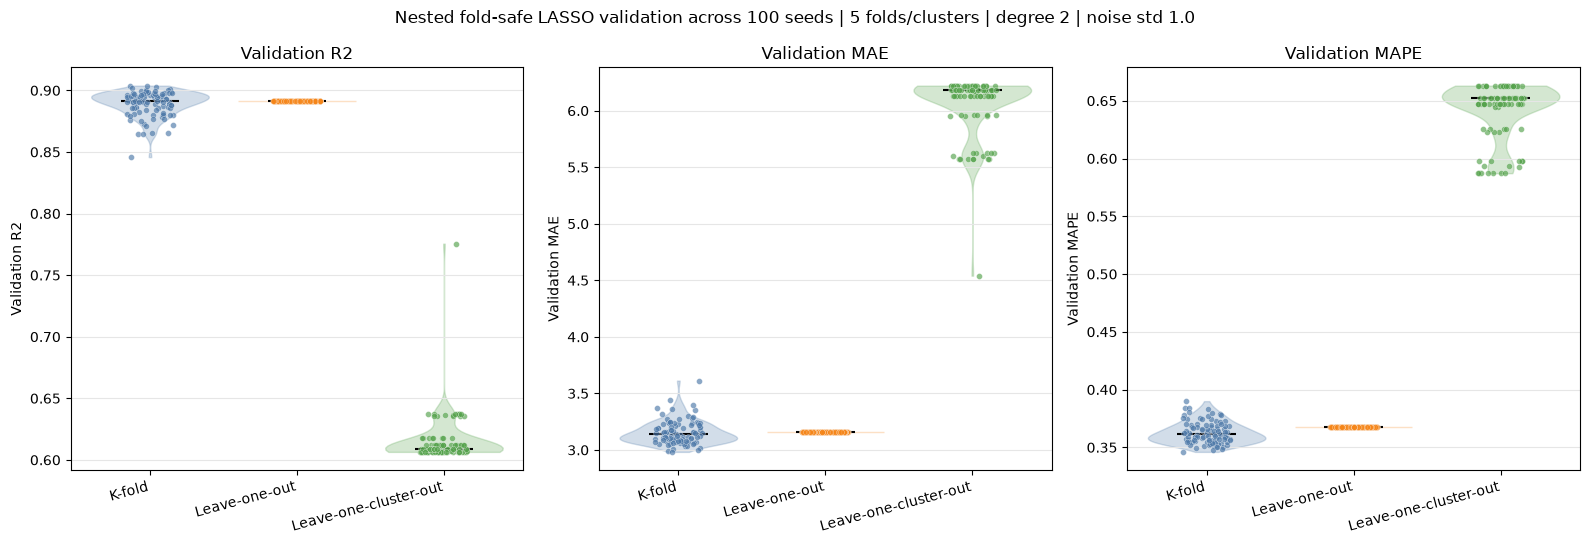

In [39]:
N_SUMMARY_SEEDS = 100
SUMMARY_SEEDS = range(N_SUMMARY_SEEDS)
SUMMARY_N_SPLITS = 5
SUMMARY_NOISE_STD = 1.0
SUMMARY_POLYNOMIAL_DEGREE = 2
CV_STRATEGIES = ["k-fold", "leave-one-out", "leave-one-cluster-out"]
CV_LABELS = {
    "k-fold": "K-fold",
    "leave-one-out": "Leave-one-out",
    "leave-one-cluster-out": "Leave-one-cluster-out",
}
CV_COLORS = {
    "k-fold": "#4c78a8",
    "leave-one-out": "#f58518",
    "leave-one-cluster-out": "#54a24b",
}

x_summary, y_summary = generate_dataset(SUMMARY_NOISE_STD)
summary_scores = {
    metric: {strategy: [] for strategy in CV_STRATEGIES}
    for metric in ["r2", "mae", "mape"]
}
prediction_cache = {}

for seed in SUMMARY_SEEDS:
    splits_by_strategy = make_cv_splits(
        x_summary, n_splits=SUMMARY_N_SPLITS, cv_seed=seed
    )
    for strategy in CV_STRATEGIES:
        splits = splits_by_strategy[strategy]
        # Reuse predictions when two seeds produce exactly the same folds.
        split_signature = tuple(
            sorted(tuple(validation_indices.tolist()) for _, validation_indices in splits)
        )
        if split_signature not in prediction_cache:
            prediction_cache[split_signature] = lasso_out_of_fold_predictions(
                x_summary,
                y_summary,
                splits,
                SUMMARY_POLYNOMIAL_DEGREE,
                standardize_globally=False,
            )
        predictions = prediction_cache[split_signature]

        summary_scores["r2"][strategy].append(r2_score(y_summary, predictions))
        summary_scores["mae"][strategy].append(
            mean_absolute_error(y_summary, predictions)
        )
        summary_scores["mape"][strategy].append(
            mean_absolute_percentage_error(y_summary, predictions)
        )

for metric_scores in summary_scores.values():
    for strategy_scores in metric_scores.values():
        assert len(strategy_scores) == N_SUMMARY_SEEDS

with plt.ioff():
    summary_figure, summary_axes = plt.subplots(1, 3, figsize=(16, 5.5))

metric_specs = [
    ("r2", "Validation R2"),
    ("mae", "Validation MAE"),
    ("mape", "Validation MAPE"),
]
positions = np.arange(1, len(CV_STRATEGIES) + 1)
jitter_rng = np.random.default_rng(420)

for axis, (metric, title) in zip(summary_axes, metric_specs):
    datasets = [np.asarray(summary_scores[metric][strategy]) for strategy in CV_STRATEGIES]
    violin_parts = axis.violinplot(
        datasets,
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    for body, strategy in zip(violin_parts["bodies"], CV_STRATEGIES):
        body.set_facecolor(CV_COLORS[strategy])
        body.set_edgecolor(CV_COLORS[strategy])
        body.set_alpha(0.25)
    violin_parts["cmedians"].set_color("black")
    violin_parts["cmedians"].set_linewidth(1.5)

    for position, strategy, values in zip(positions, CV_STRATEGIES, datasets):
        jitter = jitter_rng.uniform(-0.16, 0.16, size=len(values))
        axis.scatter(
            position + jitter,
            values,
            color=CV_COLORS[strategy],
            edgecolor="white",
            linewidth=0.3,
            alpha=0.65,
            s=18,
            zorder=3,
        )

    axis.set_xticks(positions)
    axis.set_xticklabels(
        [CV_LABELS[strategy] for strategy in CV_STRATEGIES],
        rotation=15,
        ha="right",
    )
    axis.set(title=title, ylabel=title)
    axis.grid(axis="y", color="0.9", linewidth=0.8)

summary_figure.suptitle(
    f"Nested fold-safe LASSO validation across {N_SUMMARY_SEEDS} seeds | "
    f"{SUMMARY_N_SPLITS} folds/clusters | degree {SUMMARY_POLYNOMIAL_DEGREE} | "
    f"noise std {SUMMARY_NOISE_STD:.1f}"
)
summary_figure.tight_layout()
display(summary_figure)
plt.close(summary_figure)

## 8. Exploring GIFTERS: Generalizability of Regularized Models

### 8.1 Interactive Lambda Selection

This section applies LASSO without allowing information to cross the outer train–validation boundary. Within every fold, polynomial features and standardization are fit only on the training observations; the fitted transformations are then applied to validation observations.

The **lambda** slider controls scikit-learn's `alpha` parameter in both panels. The left panel shows pooled out-of-fold validation predictions at that lambda. The right panel shows the mean standardized-feature parameter path across the outer training folds, with shading for $\pm 1$ fold-to-fold standard deviation. The red vertical line marks the selected lambda. The intercept is included as a horizontal path because it is fit but not regularized.

In [40]:
LAMBDA_GRID = np.logspace(2, -4, 121)  # matches the slider's 0.05 log10 steps

lasso_cv_type_widget = Dropdown(
    options=["k-fold", "leave-one-out", "leave-one-cluster-out"],
    value="k-fold",
    description="CV type",
)
lasso_n_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters"
)
lasso_noise_widget = BoundedFloatText(
    min=0.0, max=4.0, step=0.1, value=1.0, description="noise std"
)
lasso_cv_seed_widget = BoundedIntText(
    min=0, max=9999, step=1, value=420, description="CV seed"
)
lasso_degree_widget = IntSlider(
    min=1, max=8, step=1, value=2, description="poly degree"
)
lasso_lambda_widget = FloatLogSlider(
    value=0.1, base=10, min=-4, max=2, step=0.05,
    description="lambda", readout_format=".4g",
)

def _sync_lasso_controls(change=None):
    lasso_n_splits_widget.disabled = lasso_cv_type_widget.value == "leave-one-out"

lasso_cv_type_widget.observe(_sync_lasso_controls, names="value")
_sync_lasso_controls()

@lru_cache(maxsize=32)
def _prepare_fold_safe_lasso(cv_type, n_splits, noise_std, cv_seed, degree):
    x_current, y_current = generate_dataset(noise_std)
    splits = make_cv_splits(
        x_current, n_splits=n_splits, cv_seed=cv_seed
    )[cv_type]
    x_column = x_current.reshape(-1, 1)
    prepared_folds = []
    fold_coefficient_paths = []

    for train_indices, validation_indices in splits:
        polynomial = PolynomialFeatures(degree=degree, include_bias=False)
        scaler = StandardScaler()
        x_train = scaler.fit_transform(
            polynomial.fit_transform(x_column[train_indices])
        )
        x_validation = scaler.transform(
            polynomial.transform(x_column[validation_indices])
        )
        y_train = y_current[train_indices]
        path_lambdas, path_coefficients, _ = lasso_path(
            x_train,
            y_train - y_train.mean(),
            alphas=LAMBDA_GRID,
            max_iter=LASSO_MAX_ITER,
            tol=LASSO_TOL,
        )
        assert np.allclose(path_lambdas, LAMBDA_GRID)
        intercept_path = np.full((1, len(LAMBDA_GRID)), y_train.mean())
        parameter_paths = np.vstack([path_coefficients, intercept_path])
        prepared_folds.append(
            (validation_indices, x_validation, parameter_paths)
        )
        fold_coefficient_paths.append(parameter_paths)

    coefficient_paths = np.stack(fold_coefficient_paths)
    return (
        x_current,
        y_current,
        prepared_folds,
        coefficient_paths.mean(axis=0),
        coefficient_paths.std(axis=0),
    )

def render_interactive_lasso(cv_type, n_splits, noise_std, cv_seed, degree, lambda_value):
    x_current, y_current, prepared_folds, mean_path, std_path = _prepare_fold_safe_lasso(
        cv_type, n_splits, noise_std, cv_seed, degree
    )
    predictions = np.full(len(y_current), np.nan)
    lambda_index = np.argmin(np.abs(np.log10(LAMBDA_GRID) - np.log10(lambda_value)))
    selected_lambda = LAMBDA_GRID[lambda_index]

    for validation_indices, x_validation, parameter_paths in prepared_folds:
        predictions[validation_indices] = (
            x_validation @ parameter_paths[:-1, lambda_index]
            + parameter_paths[-1, lambda_index]
        )

    assert np.all(np.isfinite(predictions)), "Every observation must receive one finite prediction."
    validation_r2 = r2_score(y_current, predictions)
    validation_mae = mean_absolute_error(y_current, predictions)
    validation_mape = mean_absolute_percentage_error(y_current, predictions)

    parity_values = np.concatenate([y_current, predictions])
    parity_span = np.ptp(parity_values)
    parity_padding = max(0.05 * parity_span, 0.5)
    parity_limits = (
        parity_values.min() - parity_padding,
        parity_values.max() + parity_padding,
    )

    with plt.ioff():
        figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    axes[0].plot(parity_limits, parity_limits, color="0.4", linestyle="--", label="parity")
    axes[0].scatter(
        y_current, predictions, color=SAFE_COLOR, alpha=0.85,
        label="out-of-fold prediction",
    )
    axes[0].set(
        xlabel="true y",
        ylabel="out-of-fold predicted y",
        xlim=parity_limits,
        ylim=parity_limits,
        title=(
            f"Validation parity at lambda = {selected_lambda:.4g}\n"
            f"R2 = {validation_r2:.3f} | MAE = {validation_mae:.3f} | "
            f"MAPE = {validation_mape:.3f}"
        ),
    )
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].legend(loc="upper left")

    coefficient_cmap = plt.colormaps.get_cmap("viridis").resampled(degree + 1)
    for feature_index in range(degree + 1):
        color = coefficient_cmap(feature_index)
        if feature_index == degree:
            label = "intercept"
        else:
            label = "x" if feature_index == 0 else f"x^{feature_index + 1}"
        axes[1].plot(
            LAMBDA_GRID, mean_path[feature_index],
            color=color, linewidth=2, label=label,
        )
        axes[1].fill_between(
            LAMBDA_GRID,
            mean_path[feature_index] - std_path[feature_index],
            mean_path[feature_index] + std_path[feature_index],
            color=color, alpha=0.12,
        )
    axes[1].axvline(
        selected_lambda, color="red", linewidth=2,
        label=f"selected lambda = {selected_lambda:.4g}",
    )
    axes[1].axhline(0, color="0.7", linewidth=0.8)
    axes[1].set_xscale("log")
    axes[1].set_xlim(LAMBDA_GRID.min(), LAMBDA_GRID.max())
    axes[1].set(
        xlabel="lambda (scikit-learn alpha)",
        ylabel="parameter value in standardized-feature basis",
        title="Coefficient and intercept paths across training folds",
    )
    axes[1].legend(loc="best", fontsize=8, ncol=2)
    axes[1].grid(axis="x", which="both", color="0.92", linewidth=0.6)

    figure.suptitle(
        f"Fold-safe LASSO | {cv_type} | {len(prepared_folds)} folds | "
        f"degree {degree} | CV seed {cv_seed} | noise std {noise_std:.1f}"
    )
    figure.tight_layout()
    display(figure)
    plt.close(figure)

lasso_controls = VBox([
    HBox([lasso_cv_type_widget, lasso_n_splits_widget]),
    HBox([lasso_noise_widget, lasso_cv_seed_widget]),
    HBox([lasso_degree_widget, lasso_lambda_widget]),
])
lasso_output = interactive_output(render_interactive_lasso, {
    "cv_type": lasso_cv_type_widget,
    "n_splits": lasso_n_splits_widget,
    "noise_std": lasso_noise_widget,
    "cv_seed": lasso_cv_seed_widget,
    "degree": lasso_degree_widget,
    "lambda_value": lasso_lambda_widget,
})
display(VBox([lasso_controls, lasso_output]))

### 8.2 Generalizability Across CV Seeds

This view repeats the fold-safe LASSO analysis over 100 consecutive CV seeds and summarizes the full regularization path. Lambda is shown on the horizontal axis across the complete range of regularization strengths. The lambda slider moves a red reference line through both panels as a visual guide; it does not change or recompute the paths. Section 8.1 reports one CV seed, whereas this section plots the mean across the entire 100-seed window, so its mean $R^2$ can be negative even when the first seed's $R^2$ is positive.

The left panel shows the mean validation $R^2$, MAE, and MAPE at every lambda, with bands spanning $\pm$ one standard deviation across the 100 seed-level out-of-fold scores. $R^2$ and MAPE use the left vertical axis, while MAE uses a separate right vertical axis so its larger numerical scale does not obscure $R^2$ variability. The right panel mirrors Section 8.1's parameter-path view: each line is the mean standardized-feature coefficient or intercept across all outer training-fold fits, and each band shows $\pm$ one fold-to-fold standard deviation. The intercept path is horizontal because it is not regularized.

The seed control specifies the **first** seed in the 100-seed window. Leave-one-out remains deterministic, so changing that control does not change its results.

In [41]:
N_GENERALIZABILITY_SEEDS = 100

generalizability_cv_type_widget = Dropdown(
    options=["k-fold", "leave-one-out", "leave-one-cluster-out"],
    value="k-fold",
    description="CV type",
)
generalizability_n_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters"
)
generalizability_noise_widget = BoundedFloatText(
    min=0.0, max=4.0, step=0.1, value=1.0, description="noise std"
)
generalizability_first_seed_widget = BoundedIntText(
    min=0, max=9999, step=1, value=420, description="first seed"
)
generalizability_degree_widget = IntSlider(
    min=1, max=8, step=1, value=2, description="poly degree"
)
generalizability_lambda_widget = FloatLogSlider(
    value=0.1, base=10, min=-4, max=2, step=0.05,
    description="lambda", readout_format=".4g",
)

def _sync_generalizability_controls(change=None):
    generalizability_n_splits_widget.disabled = (
        generalizability_cv_type_widget.value == "leave-one-out"
    )

generalizability_cv_type_widget.observe(
    _sync_generalizability_controls, names="value"
)
_sync_generalizability_controls()

def _selected_cv_splits(cv_type, x, n_splits, cv_seed):
    if cv_type == "k-fold":
        return list(
            KFold(
                n_splits=n_splits, shuffle=True, random_state=cv_seed
            ).split(x)
        )
    if cv_type == "leave-one-out":
        return list(LeaveOneOut().split(x))
    if cv_type == "leave-one-cluster-out":
        cluster_labels = KMeans(
            n_clusters=n_splits, random_state=cv_seed, n_init=10
        ).fit_predict(x.reshape(-1, 1))
        return list(LeaveOneGroupOut().split(x, groups=cluster_labels))
    raise ValueError(f"Unknown cv_type: {cv_type}")

@lru_cache(maxsize=8)
def _compute_generalizability_paths(
    cv_type, n_splits, noise_std, first_seed, degree,
    n_seeds=N_GENERALIZABILITY_SEEDS,
):
    x_current, y_current = generate_dataset(noise_std)
    x_column = x_current.reshape(-1, 1)
    metric_paths = {metric: [] for metric in ["r2", "mae", "mape"]}
    coefficient_paths = []
    fold_path_cache = {}

    # The leave-one-out folds do not depend on the seed.
    seeds = (
        [0] * n_seeds
        if cv_type == "leave-one-out"
        else range(first_seed, first_seed + n_seeds)
    )

    for seed_index, seed in enumerate(seeds):
        splits = _selected_cv_splits(cv_type, x_current, n_splits, seed)
        seed_predictions = np.full((len(y_current), len(LAMBDA_GRID)), np.nan)

        for train_indices, validation_indices in splits:
            fold_signature = tuple(validation_indices.tolist())
            if fold_signature not in fold_path_cache:
                polynomial = PolynomialFeatures(degree=degree, include_bias=False)
                scaler = StandardScaler()
                x_train = scaler.fit_transform(
                    polynomial.fit_transform(x_column[train_indices])
                )
                x_validation = scaler.transform(
                    polynomial.transform(x_column[validation_indices])
                )
                y_train = y_current[train_indices]
                path_lambdas, fold_coefficients, _ = lasso_path(
                    x_train,
                    y_train - y_train.mean(),
                    alphas=LAMBDA_GRID,
                    max_iter=LASSO_MAX_ITER,
                    tol=LASSO_TOL,
                )
                assert np.allclose(path_lambdas, LAMBDA_GRID)
                fold_predictions = x_validation @ fold_coefficients + y_train.mean()
                intercept_path = np.full((1, len(LAMBDA_GRID)), y_train.mean())
                fold_parameter_paths = np.vstack([
                    fold_coefficients, intercept_path
                ])
                fold_path_cache[fold_signature] = (
                    fold_predictions, fold_parameter_paths
                )

            fold_predictions, fold_parameter_paths = fold_path_cache[fold_signature]
            seed_predictions[validation_indices] = fold_predictions
            # Repeating deterministic LOO paths 100 times would not change its summary.
            if cv_type != "leave-one-out" or seed_index == 0:
                coefficient_paths.append(fold_parameter_paths)

        assert np.all(np.isfinite(seed_predictions))
        residuals = y_current[:, None] - seed_predictions
        total_sum_of_squares = np.sum((y_current - y_current.mean()) ** 2)
        metric_paths["r2"].append(
            1.0 - np.sum(residuals ** 2, axis=0) / total_sum_of_squares
        )
        metric_paths["mae"].append(np.mean(np.abs(residuals), axis=0))
        mape_denominator = np.maximum(np.abs(y_current), np.finfo(float).eps)
        metric_paths["mape"].append(
            np.mean(np.abs(residuals) / mape_denominator[:, None], axis=0)
        )

    return (
        {metric: np.stack(values) for metric, values in metric_paths.items()},
        np.stack(coefficient_paths),
    )

def render_generalizability_summary(
    cv_type, n_splits, noise_std, first_seed, degree, lambda_value
):
    metric_paths, coefficient_paths = _compute_generalizability_paths(
        cv_type, n_splits, noise_std, first_seed, degree
    )
    with plt.ioff():
        figure, axes = plt.subplots(1, 2, figsize=(15, 6))

    metric_specs = [
        ("r2", "Validation R2", "#4c78a8"),
        ("mae", "Validation MAE", "#f58518"),
        ("mape", "Validation MAPE", "#54a24b"),
    ]
    metric_axis = axes[0]
    mae_axis = metric_axis.twinx()
    for metric, label, color in metric_specs:
        mean_values = metric_paths[metric].mean(axis=0)
        std_values = metric_paths[metric].std(axis=0)
        target_axis = mae_axis if metric == "mae" else metric_axis
        target_axis.plot(
            LAMBDA_GRID, mean_values, color=color, linewidth=2, label=label
        )
        target_axis.fill_between(
            LAMBDA_GRID, mean_values - std_values, mean_values + std_values,
            color=color, alpha=0.15,
        )
    metric_axis.axvline(
        lambda_value, color="red", linewidth=2,
        label=f"selected lambda = {lambda_value:.4g}",
    )
    metric_axis.set_xscale("log")
    metric_axis.set_xlim(LAMBDA_GRID.min(), LAMBDA_GRID.max())
    metric_axis.set(
        xlabel="lambda (scikit-learn alpha)",
        ylabel="validation R2 / MAPE",
        title=f"Validation metrics across {N_GENERALIZABILITY_SEEDS} CV seeds",
    )
    mae_axis.set_ylabel("validation MAE", color="#f58518")
    mae_axis.tick_params(axis="y", colors="#f58518")
    metric_handles, metric_labels = metric_axis.get_legend_handles_labels()
    mae_handles, mae_labels = mae_axis.get_legend_handles_labels()
    metric_axis.legend(
        metric_handles + mae_handles, metric_labels + mae_labels, loc="best"
    )
    metric_axis.grid(axis="x", which="both", color="0.92", linewidth=0.6)

    mean_coefficient_paths = coefficient_paths.mean(axis=0)
    std_coefficient_paths = coefficient_paths.std(axis=0)
    coefficient_cmap = plt.colormaps.get_cmap("viridis").resampled(degree + 1)
    for feature_index in range(degree + 1):
        color = coefficient_cmap(feature_index)
        if feature_index == degree:
            label = "intercept"
        else:
            label = "x" if feature_index == 0 else f"x^{feature_index + 1}"
        axes[1].plot(
            LAMBDA_GRID, mean_coefficient_paths[feature_index],
            color=color, linewidth=2, label=label,
        )
        axes[1].fill_between(
            LAMBDA_GRID,
            mean_coefficient_paths[feature_index] - std_coefficient_paths[feature_index],
            mean_coefficient_paths[feature_index] + std_coefficient_paths[feature_index],
            color=color, alpha=0.12,
        )
    axes[1].axhline(0, color="0.7", linewidth=0.8)
    axes[1].axvline(
        lambda_value, color="red", linewidth=2,
        label=f"selected lambda = {lambda_value:.4g}",
    )
    axes[1].set_xscale("log")
    axes[1].set_xlim(LAMBDA_GRID.min(), LAMBDA_GRID.max())
    axes[1].set(
        xlabel="lambda (scikit-learn alpha)",
        ylabel="parameter value in standardized-feature basis",
        title=(
            f"Coefficient and intercept paths across {coefficient_paths.shape[0]} "
            "outer training-fold fits"
        ),
    )
    axes[1].legend(loc="best", fontsize=8, ncol=2)
    axes[1].grid(axis="x", which="both", color="0.92", linewidth=0.6)

    seed_end = first_seed + N_GENERALIZABILITY_SEEDS - 1
    seed_label = "deterministic outer folds" if cv_type == "leave-one-out" else f"seeds {first_seed}-{seed_end}"
    figure.suptitle(
        f"GIFTERS generalizability | {cv_type} | {seed_label} | "
        f"degree {degree} | noise std {noise_std:.1f}",
        fontsize=13,
    )
    figure.tight_layout(rect=[0, 0, 1, 0.93])
    display(figure)
    plt.close(figure)

generalizability_controls = VBox([
    HBox([generalizability_cv_type_widget, generalizability_n_splits_widget]),
    HBox([generalizability_noise_widget, generalizability_first_seed_widget]),
    HBox([generalizability_degree_widget, generalizability_lambda_widget]),
])
generalizability_output = interactive_output(render_generalizability_summary, {
    "cv_type": generalizability_cv_type_widget,
    "n_splits": generalizability_n_splits_widget,
    "noise_std": generalizability_noise_widget,
    "first_seed": generalizability_first_seed_widget,
    "degree": generalizability_degree_widget,
    "lambda_value": generalizability_lambda_widget,
})
display(VBox([generalizability_controls, generalizability_output]))

### 8.3 Mapping "Good Enough" Generalizability

These four contour maps examine the interaction between model complexity and regularization over 30 consecutive CV seeds. The columns compare shuffled K-fold CV with leave-one-cluster-out CV. The top row shows the **mean out-of-fold validation $R^2$**, while the bottom row shows its **standard deviation across seeds**. Together they compare average predictive performance and split sensitivity under both validation strategies. Section 8.2 retains its larger 100-seed summary.

All panels use lambda on a logarithmic horizontal axis and polynomial order on the vertical axis. The K-fold count and LOCO cluster count are controlled by one shared slider. Mean panels share one fixed color scale, and standard-deviation panels share one logarithmic color scale because instability spans several orders of magnitude. No universal cutoff for "good enough" is imposed; the maps provide the evidence needed to choose a context-appropriate combination of high mean performance and low validation variability under both strategies.

Polynomial orders 1 through 7 are included. Reducing this interactive surface to 30 seeds makes degree 7 practical while retaining enough resamples to expose split sensitivity. Degree 8 remains excluded because it still reaches the solver's iteration limit near the weakest penalties. Slider changes are applied only when the control is released.

In [42]:
GOOD_ENOUGH_ORDERS = np.arange(1, 8)
GOOD_ENOUGH_FIRST_SEED = 420
N_GOOD_ENOUGH_SEEDS = 30
R2_STD_FLOOR = 1e-6

good_enough_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters",
    continuous_update=False,
)
good_enough_noise_widget = FloatSlider(
    min=0.0, max=4.0, step=0.1, value=1.0, description="noise std",
    readout_format=".1f", continuous_update=False,
)

@lru_cache(maxsize=4)
def _compute_good_enough_surfaces(n_splits, noise_std):
    kfold_mean_r2 = []
    kfold_std_r2 = []
    loco_mean_r2 = []
    loco_std_r2 = []

    for degree in GOOD_ENOUGH_ORDERS:
        kfold_metrics, _ = _compute_generalizability_paths(
            "k-fold", n_splits, noise_std, GOOD_ENOUGH_FIRST_SEED,
            int(degree), N_GOOD_ENOUGH_SEEDS,
        )
        loco_metrics, _ = _compute_generalizability_paths(
            "leave-one-cluster-out",
            n_splits,
            noise_std,
            GOOD_ENOUGH_FIRST_SEED,
            int(degree),
            N_GOOD_ENOUGH_SEEDS,
        )
        kfold_mean_r2.append(kfold_metrics["r2"].mean(axis=0))
        kfold_std_r2.append(kfold_metrics["r2"].std(axis=0))
        loco_mean_r2.append(loco_metrics["r2"].mean(axis=0))
        loco_std_r2.append(loco_metrics["r2"].std(axis=0))

    return (
        np.stack(kfold_mean_r2),
        np.stack(kfold_std_r2),
        np.stack(loco_mean_r2),
        np.stack(loco_std_r2),
    )

def render_good_enough_generalizability(n_splits, noise_std):
    (
        kfold_mean_r2, kfold_std_r2, loco_mean_r2, loco_std_r2
    ) = _compute_good_enough_surfaces(n_splits, noise_std)
    lambda_axis = LAMBDA_GRID[::-1]
    mean_surfaces = [kfold_mean_r2[:, ::-1], loco_mean_r2[:, ::-1]]
    std_surfaces = [kfold_std_r2[:, ::-1], loco_std_r2[:, ::-1]]

    with plt.ioff():
        figure, axes = plt.subplots(
            2, 2, figsize=(15, 11), sharex=True, sharey=True,
            constrained_layout=True,
        )

    mean_levels = np.linspace(-1.0, 1.0, 21)
    mean_contours = []
    for axis, surface in zip(axes[0], mean_surfaces):
        filled_contours = axis.contourf(
            lambda_axis, GOOD_ENOUGH_ORDERS, surface,
            levels=mean_levels, cmap="RdYlGn", extend="min",
        )
        mean_contours.append(filled_contours)
        reference_levels = [
            level for level in [0.0, 0.5, 0.8]
            if surface.min() < level < surface.max()
        ]
        if reference_levels:
            reference_contours = axis.contour(
                lambda_axis, GOOD_ENOUGH_ORDERS, surface,
                levels=reference_levels, colors="black", linewidths=0.8,
            )
            axis.clabel(reference_contours, fmt="R2 = %.1f", fontsize=8)
    figure.colorbar(
        mean_contours[0], ax=axes[0].tolist(), label="mean validation R2"
    )

    std_ceiling = max(
        max(float(np.nanmax(surface)) for surface in std_surfaces),
        R2_STD_FLOOR * 10,
    )
    std_levels = np.geomspace(R2_STD_FLOOR, std_ceiling, 21)
    std_contours = []
    for axis, surface in zip(axes[1], std_surfaces):
        filled_contours = axis.contourf(
            lambda_axis,
            GOOD_ENOUGH_ORDERS,
            np.maximum(surface, R2_STD_FLOOR),
            levels=std_levels,
            norm=LogNorm(vmin=R2_STD_FLOOR, vmax=std_ceiling),
            cmap="magma",
            extend="max",
        )
        std_contours.append(filled_contours)
    figure.colorbar(
        std_contours[0], ax=axes[1].tolist(),
        label="standard deviation of validation R2 (log color scale)",
    )

    panel_titles = [
        ["K-fold: mean validation R2", "LOCO: mean validation R2"],
        ["K-fold: validation R2 standard deviation", "LOCO: validation R2 standard deviation"],
    ]
    for row_index in range(2):
        for column_index in range(2):
            axis = axes[row_index, column_index]
            axis.set_xscale("log")
            axis.set_xlim(lambda_axis.min(), lambda_axis.max())
            axis.set_yticks(GOOD_ENOUGH_ORDERS)
            axis.set(
                xlabel="lambda (scikit-learn alpha)",
                ylabel="polynomial order",
                title=panel_titles[row_index][column_index],
            )

    seed_end = GOOD_ENOUGH_FIRST_SEED + N_GOOD_ENOUGH_SEEDS - 1
    figure.suptitle(
        f"GIFTERS generalizability maps across {N_GOOD_ENOUGH_SEEDS} seeds | "
        f"seeds {GOOD_ENOUGH_FIRST_SEED}-{seed_end} | "
        f"{n_splits} folds/clusters | noise std {noise_std:.1f}",
        fontsize=13,
    )
    display(figure)
    plt.close(figure)

good_enough_controls = HBox([
    good_enough_splits_widget, good_enough_noise_widget,
])
good_enough_output = interactive_output(render_good_enough_generalizability, {
    "n_splits": good_enough_splits_widget,
    "noise_std": good_enough_noise_widget,
})
display(VBox([good_enough_controls, good_enough_output]))

## 9. Interpretability

### 9.1 Coefficient Stability Across CV Seeds

These panels compare fourth- and fifth-order LASSO models at $\lambda=10^{-2}$, the strongly regularized edge of the stable region identified in Section 8. Each point represents one outer training-fold fit from one of 100 CV seeds. With five folds or clusters, each coefficient therefore has 500 displayed estimates. The violin summarizes the complete fold-level distribution without averaging coefficients within seeds.

The columns compare shuffled K-fold and leave-one-cluster-out validation, while the rows compare maximum polynomial order. Each fold still fits its polynomial transformer and scaler using training data only. After fitting, coefficients and the intercept are converted from standardized-feature coordinates back to the original polynomial basis, allowing direct comparison with the known quartic parameters shown as red diamonds.

Stable coefficient distributions support a consistent interpretation; wide, multimodal, or sign-changing distributions warn that similar predictions can be produced by materially different explanations. Because folds and repeated-seed partitions overlap, these points are not statistically independent.

In [43]:
INTERPRETABILITY_DEGREES = (4, 5)
INTERPRETABILITY_LAMBDA = 1e-2
N_INTERPRETABILITY_SEEDS = 100
INTERPRETABILITY_FIRST_SEED = 420

interpretability_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters",
    continuous_update=False,
)
interpretability_noise_widget = FloatSlider(
    min=0.0, max=4.0, step=0.1, value=1.0, description="noise std",
    readout_format=".1f", continuous_update=False,
)

def _ground_truth_model_parameters(degree):
    quartic_terms_ascending = TRUE_COEFFICIENTS[-2::-1]
    polynomial_coefficients = np.pad(
        quartic_terms_ascending,
        (0, max(degree - len(quartic_terms_ascending), 0)),
    )[:degree]
    return np.concatenate([polynomial_coefficients, [TRUE_COEFFICIENTS[-1]]])

@lru_cache(maxsize=4)
def _compute_interpretability_coefficients(n_splits, noise_std):
    x_current, y_current = generate_dataset(noise_std)
    x_column = x_current.reshape(-1, 1)
    coefficient_results = {}

    for cv_type in ["k-fold", "leave-one-cluster-out"]:
        for degree in INTERPRETABILITY_DEGREES:
            fold_coefficients_across_seeds = []
            fold_coefficient_cache = {}

            for seed in range(
                INTERPRETABILITY_FIRST_SEED,
                INTERPRETABILITY_FIRST_SEED + N_INTERPRETABILITY_SEEDS,
            ):
                splits = _selected_cv_splits(
                    cv_type, x_current, n_splits, seed
                )
                for train_indices, validation_indices in splits:
                    fold_signature = tuple(validation_indices.tolist())
                    if fold_signature not in fold_coefficient_cache:
                        polynomial = PolynomialFeatures(
                            degree=degree, include_bias=False
                        )
                        scaler = StandardScaler()
                        x_train = scaler.fit_transform(
                            polynomial.fit_transform(x_column[train_indices])
                        )
                        y_train = y_current[train_indices]
                        _, standardized_coefficients, _ = lasso_path(
                            x_train,
                            y_train - y_train.mean(),
                            alphas=[INTERPRETABILITY_LAMBDA],
                            max_iter=LASSO_MAX_ITER,
                            tol=LASSO_TOL,
                        )
                        original_basis_coefficients = (
                            standardized_coefficients[:, 0] / scaler.scale_
                        )
                        original_basis_intercept = (
                            y_train.mean()
                            - standardized_coefficients[:, 0]
                            @ (scaler.mean_ / scaler.scale_)
                        )
                        original_basis_parameters = np.concatenate([
                            original_basis_coefficients,
                            [original_basis_intercept],
                        ])
                        fold_coefficient_cache[fold_signature] = (
                            original_basis_parameters
                        )

                    fold_coefficients_across_seeds.append(
                        fold_coefficient_cache[fold_signature]
                    )

            coefficient_results[(cv_type, degree)] = np.stack(
                fold_coefficients_across_seeds
            )

    return coefficient_results

def render_interpretability_coefficients(n_splits, noise_std):
    coefficient_results = _compute_interpretability_coefficients(
        n_splits, noise_std
    )
    with plt.ioff():
        figure, axes = plt.subplots(
            2, 2, figsize=(15, 10), sharey=True, constrained_layout=True
        )

    jitter_rng = np.random.default_rng(420)
    column_specs = [
        ("k-fold", "K-fold"),
        ("leave-one-cluster-out", "LOCO"),
    ]
    coefficient_cmap = plt.colormaps.get_cmap("viridis").resampled(6)

    for row_index, degree in enumerate(INTERPRETABILITY_DEGREES):
        true_parameters = _ground_truth_model_parameters(degree)
        positions = np.arange(1, degree + 2)
        for column_index, (cv_type, cv_label) in enumerate(column_specs):
            axis = axes[row_index, column_index]
            fold_coefficients = coefficient_results[(cv_type, degree)]
            coefficient_distributions = [
                fold_coefficients[:, feature_index]
                for feature_index in range(degree + 1)
            ]
            violins = axis.violinplot(
                coefficient_distributions,
                positions=positions,
                widths=0.8,
                showmeans=False,
                showmedians=True,
                showextrema=False,
                quantiles=[[0.25, 0.75] for _ in positions],
            )
            for feature_index, body in enumerate(violins["bodies"]):
                color = coefficient_cmap(feature_index)
                body.set_facecolor(color)
                body.set_edgecolor(color)
                body.set_alpha(0.3)
                jitter = jitter_rng.uniform(
                    -0.16, 0.16, len(coefficient_distributions[feature_index])
                )
                axis.scatter(
                    positions[feature_index] + jitter,
                    coefficient_distributions[feature_index],
                    color=color, edgecolor="white", linewidth=0.25,
                    alpha=0.18, s=8, zorder=3,
                )
            violins["cmedians"].set_color("black")
            violins["cmedians"].set_linewidth(1.5)
            violins["cquantiles"].set_color("black")
            violins["cquantiles"].set_linewidth(2.0)
            axis.scatter(
                positions, true_parameters, color="red", marker="D",
                edgecolor="white", linewidth=0.6, s=48, zorder=4,
                label="ground truth",
            )
            axis.axhline(0, color="0.65", linewidth=0.8)
            axis.set_xticks(positions)
            axis.set_xticklabels(
                ["x" if power == 1 else f"x^{power}" for power in range(1, degree + 1)]
                + ["intercept"]
            )
            axis.set(
                xlabel="polynomial term",
                ylabel="parameter value in original polynomial basis",
                title=(
                    f"{cv_label} | degree {degree} | "
                    f"{len(fold_coefficients)} fold fits"
                ),
            )
            axis.grid(axis="y", color="0.92", linewidth=0.7)
            axis.legend(loc="best", fontsize=8)

    seed_end = INTERPRETABILITY_FIRST_SEED + N_INTERPRETABILITY_SEEDS - 1
    figure.suptitle(
        f"Coefficient stability at lambda = {INTERPRETABILITY_LAMBDA:.3g} | "
        f"seeds {INTERPRETABILITY_FIRST_SEED}-{seed_end} | "
        f"{n_splits} folds/clusters | noise std {noise_std:.1f}",
        fontsize=13,
    )
    display(figure)
    plt.close(figure)

interpretability_controls = HBox([
    interpretability_splits_widget, interpretability_noise_widget,
])
interpretability_output = interactive_output(
    render_interpretability_coefficients,
    {
        "n_splits": interpretability_splits_widget,
        "noise_std": interpretability_noise_widget,
    },
)
display(VBox([interpretability_controls, interpretability_output]))

## 10. Robustness

### 10.1 Robustness to Feature and Output Noise

This section compares the selected fourth- and fifth-order models at $\lambda=10^{-2}$, then studies how measurement noise changes their validation performance. Both axes use dimensionless relative noise: $r_x=\sigma_{\epsilon_x}/s_x$ and $r_y=\sigma_{\epsilon_y}/s_y$, where $s_x=\operatorname{SD}(x_{\mathrm{clean}})$ and $s_y=\operatorname{SD}(y_{\mathrm{clean}})$ are population standard deviations of the same clean 60 observations used in the experiment. Consequently, $x_{\mathrm{obs}}=x_{\mathrm{clean}}+r_xs_xz_x$ and $y_{\mathrm{obs}}=f(x_{\mathrm{clean}})+r_ys_yz_y$, with independent standard-normal vectors $z_x$ and $z_y$. Relative input noise focuses on 0 to 0.2, while relative output noise spans 0 to 0.5; equal numerical values remain comparable fractions of their respective reference variation. This remains an errors-in-variables setting because output targets are tied to the latent clean $x$ locations.

One pair of standard-normal noise vectors is drawn and scaled across the entire grid. This controlled single realization makes changes across noise levels smooth and attributable to noise magnitude rather than to a new random draw at every grid point. At each grid point, seeds 420 through 519 vary only the cross-validation partitions. R² is evaluated against the noisy held-out observations because those are the measurements available to the model.

As in Section 9.1, rows distinguish polynomial orders 4 and 5, while columns compare shuffled K-fold CV and K-cluster LOCO. The **folds/clusters** slider updates both columns together. In every panel, filled color shows the mean out-of-fold validation R² across 100 CV seeds and dashed contour lines show its standard deviation. These standard deviations measure sensitivity to the validation partition conditional on this one noisy dataset, not uncertainty across repeated noise realizations. Results for every slider setting were calculated once with `generate_lasso_robustness_results.py`, saved in the repository, and are retrieved without refitting models.

In [ ]:
ROBUSTNESS_DEGREES = (4, 5)
ROBUSTNESS_LAMBDA = 1e-2
ROBUSTNESS_FIRST_SEED = 420
N_ROBUSTNESS_SEEDS = 100
ROBUSTNESS_NOISE_SEED = 314159
FEATURE_RELATIVE_NOISE_LEVELS = np.round(np.arange(6) * 0.04, 2)
OUTPUT_RELATIVE_NOISE_LEVELS = np.round(np.arange(6) * 0.1, 1)
robustness_x_clean, robustness_y_clean = generate_dataset(noise_std=0.0)
FEATURE_NOISE_REFERENCE_SCALE = np.std(robustness_x_clean)
OUTPUT_NOISE_REFERENCE_SCALE = np.std(robustness_y_clean)
ROBUSTNESS_RESULTS_CANDIDATES = [
    REPO_ROOT / "demonstrations" / "data"
    / "lasso_cv_robustness_results.npz",
    Path.cwd() / "data" / "lasso_cv_robustness_results.npz",
    Path.cwd() / "demonstrations" / "data"
    / "lasso_cv_robustness_results.npz",
]
ROBUSTNESS_RESULTS_PATH = next(
    (path for path in ROBUSTNESS_RESULTS_CANDIDATES if path.exists()),
    ROBUSTNESS_RESULTS_CANDIDATES[0],
)

robustness_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters",
    continuous_update=False,
)

def add_observation_noise(
    x, y, feature_relative_noise, output_relative_noise,
    noise_seed=ROBUSTNESS_NOISE_SEED,
):
    if feature_relative_noise < 0 or output_relative_noise < 0:
        raise ValueError("Relative noise levels must be non-negative.")
    rng = np.random.default_rng(noise_seed)
    feature_noise = rng.normal(size=len(x))
    output_noise = rng.normal(size=len(y))
    return (
        np.asarray(x)
        + feature_relative_noise * np.std(x) * feature_noise,
        np.asarray(y)
        + output_relative_noise * np.std(y) * output_noise,
    )

def _robustness_fold_prediction(
    x, y, train_indices, validation_indices, degree, lambda_value
):
    polynomial = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    x_column = x.reshape(-1, 1)
    x_train = scaler.fit_transform(
        polynomial.fit_transform(x_column[train_indices])
    )
    x_validation = scaler.transform(
        polynomial.transform(x_column[validation_indices])
    )
    y_train = y[train_indices]
    _, coefficients, _ = lasso_path(
        x_train,
        y_train - y_train.mean(),
        alphas=[lambda_value],
        max_iter=LASSO_MAX_ITER,
        tol=LASSO_TOL,
    )
    return x_validation @ coefficients[:, 0] + y_train.mean()

def _robustness_r2_across_seeds(x, y, cv_type, degree, n_splits):
    seed_scores = []
    fold_prediction_cache = {}
    for cv_seed in range(
        ROBUSTNESS_FIRST_SEED,
        ROBUSTNESS_FIRST_SEED + N_ROBUSTNESS_SEEDS,
    ):
        splits = _selected_cv_splits(
            cv_type, x, n_splits, cv_seed
        )
        predictions = np.full(len(y), np.nan)
        for train_indices, validation_indices in splits:
            fold_signature = tuple(validation_indices.tolist())
            if fold_signature not in fold_prediction_cache:
                fold_prediction_cache[fold_signature] = _robustness_fold_prediction(
                    x,
                    y,
                    train_indices,
                    validation_indices,
                    degree,
                    ROBUSTNESS_LAMBDA,
                )
            predictions[validation_indices] = fold_prediction_cache[fold_signature]
        assert np.all(np.isfinite(predictions))
        seed_scores.append(r2_score(y, predictions))
    return np.asarray(seed_scores)

@lru_cache(maxsize=11)
def _compute_robustness_surfaces_from_fits(n_splits):
    x_clean, y_clean = generate_dataset(noise_std=0.0)
    surface_keys = [
        (degree, cv_type)
        for degree in ROBUSTNESS_DEGREES
        for cv_type in ["k-fold", "leave-one-cluster-out"]
    ]
    surfaces = {
        key: {"mean": [], "std": []} for key in surface_keys
    }

    for output_relative_noise in OUTPUT_RELATIVE_NOISE_LEVELS:
        row_scores = {
            key: {"mean": [], "std": []} for key in surface_keys
        }
        for feature_relative_noise in FEATURE_RELATIVE_NOISE_LEVELS:
            x_noisy, y_noisy = add_observation_noise(
                x_clean,
                y_clean,
                feature_relative_noise,
                output_relative_noise,
            )
            for degree, cv_type in surface_keys:
                seed_scores = _robustness_r2_across_seeds(
                    x_noisy, y_noisy, cv_type, degree, n_splits
                )
                key = (degree, cv_type)
                row_scores[key]["mean"].append(seed_scores.mean())
                row_scores[key]["std"].append(seed_scores.std())

        for key in surface_keys:
            for statistic in ["mean", "std"]:
                surfaces[key][statistic].append(
                    row_scores[key][statistic]
                )

    return {
        key: {
            statistic: np.asarray(values)
            for statistic, values in statistics.items()
        }
        for key, statistics in surfaces.items()
    }

@lru_cache(maxsize=1)
def _load_robustness_results():
    if not ROBUSTNESS_RESULTS_PATH.exists():
        raise FileNotFoundError(
            f"Missing {ROBUSTNESS_RESULTS_PATH}. Regenerate it with "
            "python demonstrations/generate_lasso_robustness_results.py"
        )
    with np.load(ROBUSTNESS_RESULTS_PATH, allow_pickle=False) as bundle:
        results = {name: bundle[name].copy() for name in bundle.files}

    expected_metadata = {
        "schema_version": 4,
        "degrees": np.asarray(ROBUSTNESS_DEGREES),
        "cv_types": np.asarray(["k-fold", "leave-one-cluster-out"]),
        "feature_relative_noise_levels": FEATURE_RELATIVE_NOISE_LEVELS,
        "output_relative_noise_levels": OUTPUT_RELATIVE_NOISE_LEVELS,
        "feature_reference_scale": FEATURE_NOISE_REFERENCE_SCALE,
        "output_reference_scale": OUTPUT_NOISE_REFERENCE_SCALE,
        "lambda_value": ROBUSTNESS_LAMBDA,
        "first_seed": ROBUSTNESS_FIRST_SEED,
        "n_r2_seeds": N_ROBUSTNESS_SEEDS,
        "n_parameter_seeds": 30,
        "noise_seed": ROBUSTNESS_NOISE_SEED,
    }
    for name, expected_value in expected_metadata.items():
        if not np.array_equal(results[name], expected_value):
            raise RuntimeError(
                f"Precomputed robustness metadata mismatch for {name}. "
                "Regenerate the results file before running this notebook."
            )
    return results

def _robustness_split_index(results, n_splits):
    matches = np.flatnonzero(results["split_counts"] == n_splits)
    if len(matches) != 1:
        raise ValueError(f"No precomputed result for {n_splits} folds/clusters")
    return int(matches[0])

@lru_cache(maxsize=11)
def _precomputed_robustness_surfaces(n_splits):
    results = _load_robustness_results()
    split_index = _robustness_split_index(results, n_splits)
    return {
        (degree, cv_type): {
            "mean": results["r2_mean"][
                split_index, degree_index, cv_index
            ],
            "std": results["r2_std"][
                split_index, degree_index, cv_index
            ],
        }
        for degree_index, degree in enumerate(ROBUSTNESS_DEGREES)
        for cv_index, cv_type in enumerate(
            ["k-fold", "leave-one-cluster-out"]
        )
    }

def render_robustness_surfaces(n_splits):
    robustness_surfaces = _precomputed_robustness_surfaces(n_splits)

    with plt.ioff():
        robustness_figure, robustness_axes = plt.subplots(
            2, 2, figsize=(15, 11), sharex=True, sharey=True,
            constrained_layout=True,
        )

    cv_columns = ["k-fold", "leave-one-cluster-out"]
    cv_titles = ["K-fold", "LOCO"]
    mean_levels = np.linspace(-1.0, 1.0, 21)
    all_std_surfaces = [
        robustness_surfaces[(degree, cv_type)]["std"]
        for degree in ROBUSTNESS_DEGREES
        for cv_type in cv_columns
    ]
    global_std_min = min(
        float(surface.min()) for surface in all_std_surfaces
    )
    global_std_max = max(
        float(surface.max()) for surface in all_std_surfaces
    )
    candidate_std_levels = np.asarray([
        0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0
    ])
    std_line_levels = candidate_std_levels[
        (candidate_std_levels > global_std_min)
        & (candidate_std_levels < global_std_max)
    ]
    if len(std_line_levels) < 2 and global_std_max > global_std_min:
        std_line_levels = np.linspace(
            global_std_min, global_std_max, 4
        )[1:-1]

    mean_contours = []
    for row_index, degree in enumerate(ROBUSTNESS_DEGREES):
        for column_index, (cv_type, cv_title) in enumerate(
            zip(cv_columns, cv_titles)
        ):
            axis = robustness_axes[row_index, column_index]
            mean_surface = robustness_surfaces[(degree, cv_type)]["mean"]
            std_surface = robustness_surfaces[(degree, cv_type)]["std"]
            filled_contours = axis.contourf(
                FEATURE_RELATIVE_NOISE_LEVELS,
                OUTPUT_RELATIVE_NOISE_LEVELS, mean_surface,
                levels=mean_levels, cmap="RdYlGn", extend="min",
            )
            mean_contours.append(filled_contours)

            reference_levels = [
                level for level in [0.0, 0.5, 0.8]
                if mean_surface.min() < level < mean_surface.max()
            ]
            if reference_levels:
                reference_contours = axis.contour(
                    FEATURE_RELATIVE_NOISE_LEVELS,
                    OUTPUT_RELATIVE_NOISE_LEVELS, mean_surface,
                    levels=reference_levels, colors="black", linewidths=0.8,
                )
                axis.clabel(
                    reference_contours, fmt="R2 = %.1f", fontsize=8
                )

            panel_std_levels = std_line_levels[
                (std_line_levels > std_surface.min())
                & (std_line_levels < std_surface.max())
            ]
            if len(panel_std_levels):
                std_contours = axis.contour(
                    FEATURE_RELATIVE_NOISE_LEVELS,
                    OUTPUT_RELATIVE_NOISE_LEVELS, std_surface,
                    levels=panel_std_levels, colors="white",
                    linestyles="--", linewidths=1.2,
                )
                axis.clabel(std_contours, fmt="SD = %.2g", fontsize=8)

            axis.set(
                xlabel=(
                    r"relative feature noise $r_x=\sigma_{\epsilon_x}/"
                    r"\mathrm{SD}(x_{\mathrm{clean}})$"
                ),
                ylabel=(
                    r"relative output noise $r_y=\sigma_{\epsilon_y}/"
                    r"\mathrm{SD}(y_{\mathrm{clean}})$"
                ),
                title=f"Degree {degree} | {cv_title}",
            )

    robustness_figure.colorbar(
        mean_contours[0], ax=robustness_axes.ravel().tolist(),
        label="mean validation R2 (dashed lines show SD)",
    )

    robustness_seed_end = (
        ROBUSTNESS_FIRST_SEED + N_ROBUSTNESS_SEEDS - 1
    )
    robustness_figure.suptitle(
        f"Robustness of degree-4 and degree-5 LASSO at "
        f"lambda = {ROBUSTNESS_LAMBDA:.3g} | "
        f"seeds {ROBUSTNESS_FIRST_SEED}-{robustness_seed_end} | "
        f"{n_splits} folds/clusters\n"
        f"reference scales: SD(x_clean) = "
        f"{FEATURE_NOISE_REFERENCE_SCALE:.3f}, SD(y_clean) = "
        f"{OUTPUT_NOISE_REFERENCE_SCALE:.3f}",
        fontsize=13,
    )
    display(robustness_figure)
    plt.close(robustness_figure)

robustness_output = interactive_output(
    render_robustness_surfaces,
    {"n_splits": robustness_splits_widget},
)
display(VBox([robustness_splits_widget, robustness_output]))

### 10.2 Coefficient Stability Under Feature and Output Noise

This view applies the same controlled feature- and output-noise grid to the fitted parameters. Rows again distinguish fourth- and fifth-order models, while columns compare K-fold and LOCO-CV. Use the **parameter** slider to inspect each polynomial coefficient or the intercept, and use **folds/clusters** to update both validation strategies together. The $x^5$ panel is intentionally unavailable for the fourth-order model.

For each grid point, every fold-level parameter estimate from 30 CV seeds is retained in the original polynomial basis. Filled color shows the mean parameter value, dashed white contours show its standard deviation, and a solid black contour marks the ground-truth value when it falls within the plotted range. Thus, this view separates systematic coefficient drift from sensitivity to the validation partition. One fixed pair of Gaussian noise vectors is scaled across the grid, as in Section 10.1. All parameters and folds/clusters settings are retrieved from the same precomputed repository file, so both sliders update without refitting models.

In [45]:
COEFFICIENT_ROBUSTNESS_LAMBDA = 1e-2
COEFFICIENT_ROBUSTNESS_FIRST_SEED = 420
N_COEFFICIENT_ROBUSTNESS_SEEDS = 30
COEFFICIENT_PARAMETER_OPTIONS = [
    ("x", 1), ("x²", 2), ("x³", 3),
    ("x⁴", 4), ("x⁵", 5), ("intercept", 0),
]

coefficient_robustness_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters",
    continuous_update=False,
)
coefficient_parameter_widget = SelectionSlider(
    options=COEFFICIENT_PARAMETER_OPTIONS, value=1,
    description="parameter", continuous_update=False,
)

def _coefficient_robustness_fold_parameters(
    x, y, train_indices, degree, lambda_value
):
    polynomial = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    x_train = scaler.fit_transform(
        polynomial.fit_transform(x[train_indices].reshape(-1, 1))
    )
    y_train = y[train_indices]
    _, standardized_coefficients, _ = lasso_path(
        x_train,
        y_train - y_train.mean(),
        alphas=[lambda_value],
        max_iter=LASSO_MAX_ITER,
        tol=LASSO_TOL,
    )
    standardized_coefficients = standardized_coefficients[:, 0]
    original_basis_coefficients = standardized_coefficients / scaler.scale_
    original_basis_intercept = (
        y_train.mean()
        - standardized_coefficients @ (scaler.mean_ / scaler.scale_)
    )
    return np.concatenate([
        original_basis_coefficients, [original_basis_intercept]
    ])

def _coefficient_robustness_fold_samples(
    x, y, cv_type, degree, n_splits
):
    fold_parameters = []
    fold_parameter_cache = {}
    for cv_seed in range(
        COEFFICIENT_ROBUSTNESS_FIRST_SEED,
        COEFFICIENT_ROBUSTNESS_FIRST_SEED
        + N_COEFFICIENT_ROBUSTNESS_SEEDS,
    ):
        splits = _selected_cv_splits(cv_type, x, n_splits, cv_seed)
        for train_indices, validation_indices in splits:
            fold_signature = tuple(validation_indices.tolist())
            if fold_signature not in fold_parameter_cache:
                fold_parameter_cache[fold_signature] = (
                    _coefficient_robustness_fold_parameters(
                        x, y, train_indices, degree,
                        COEFFICIENT_ROBUSTNESS_LAMBDA,
                    )
                )
            fold_parameters.append(fold_parameter_cache[fold_signature])
    return np.stack(fold_parameters)

@lru_cache(maxsize=11)
def _compute_coefficient_robustness_surfaces_from_fits(n_splits):
    x_clean, y_clean = generate_dataset(noise_std=0.0)
    surface_keys = [
        (degree, cv_type)
        for degree in ROBUSTNESS_DEGREES
        for cv_type in ["k-fold", "leave-one-cluster-out"]
    ]
    surfaces = {
        key: {"mean": [], "std": []} for key in surface_keys
    }

    for output_relative_noise in OUTPUT_RELATIVE_NOISE_LEVELS:
        row_statistics = {
            key: {"mean": [], "std": []} for key in surface_keys
        }
        for feature_relative_noise in FEATURE_RELATIVE_NOISE_LEVELS:
            x_noisy, y_noisy = add_observation_noise(
                x_clean, y_clean,
                feature_relative_noise, output_relative_noise
            )
            for degree, cv_type in surface_keys:
                fold_samples = _coefficient_robustness_fold_samples(
                    x_noisy, y_noisy, cv_type, degree, n_splits
                )
                key = (degree, cv_type)
                row_statistics[key]["mean"].append(
                    fold_samples.mean(axis=0)
                )
                row_statistics[key]["std"].append(
                    fold_samples.std(axis=0)
                )

        for key in surface_keys:
            for statistic in ["mean", "std"]:
                surfaces[key][statistic].append(
                    row_statistics[key][statistic]
                )

    return {
        key: {
            statistic: np.asarray(values)
            for statistic, values in statistics.items()
        }
        for key, statistics in surfaces.items()
    }

@lru_cache(maxsize=11)
def _precomputed_coefficient_robustness_surfaces(n_splits):
    results = _load_robustness_results()
    if int(results["n_parameter_seeds"]) != N_COEFFICIENT_ROBUSTNESS_SEEDS:
        raise RuntimeError(
            "The precomputed coefficient seed count does not match "
            "Section 10.2. Regenerate the results file."
        )
    split_index = _robustness_split_index(results, n_splits)
    surfaces = {}
    for degree_index, degree in enumerate(ROBUSTNESS_DEGREES):
        parameter_indices = [0, 1, 2, 3, 5] if degree == 4 else list(range(6))
        for cv_index, cv_type in enumerate(
            ["k-fold", "leave-one-cluster-out"]
        ):
            surfaces[(degree, cv_type)] = {
                "mean": np.take(
                    results["parameter_mean"][
                        split_index, degree_index, cv_index
                    ],
                    parameter_indices, axis=-1,
                ),
                "std": np.take(
                    results["parameter_std"][
                        split_index, degree_index, cv_index
                    ],
                    parameter_indices, axis=-1,
                ),
            }
    return surfaces

def _coefficient_parameter_index(degree, selected_power):
    if selected_power == 0:
        return degree
    if selected_power > degree:
        return None
    return selected_power - 1

def _coefficient_parameter_label(selected_power):
    return {
        0: "intercept", 1: "x", 2: "x²", 3: "x³",
        4: "x⁴", 5: "x⁵",
    }[selected_power]

def render_coefficient_robustness(n_splits, selected_power):
    surfaces = _precomputed_coefficient_robustness_surfaces(n_splits)
    selected_label = _coefficient_parameter_label(selected_power)
    cv_columns = ["k-fold", "leave-one-cluster-out"]
    cv_titles = ["K-fold", "LOCO"]

    available_mean_surfaces = []
    available_std_surfaces = []
    for degree in ROBUSTNESS_DEGREES:
        parameter_index = _coefficient_parameter_index(
            degree, selected_power
        )
        if parameter_index is None:
            continue
        for cv_type in cv_columns:
            available_mean_surfaces.append(
                surfaces[(degree, cv_type)]["mean"][..., parameter_index]
            )
            available_std_surfaces.append(
                surfaces[(degree, cv_type)]["std"][..., parameter_index]
            )

    mean_limit = max(
        max(float(np.max(np.abs(surface)))
            for surface in available_mean_surfaces),
        1e-9,
    )
    mean_levels = np.linspace(-mean_limit, mean_limit, 21)
    global_std_min = min(
        float(surface.min()) for surface in available_std_surfaces
    )
    global_std_max = max(
        float(surface.max()) for surface in available_std_surfaces
    )
    candidate_std_levels = np.asarray([
        0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1,
        0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0,
    ])
    std_line_levels = candidate_std_levels[
        (candidate_std_levels > global_std_min)
        & (candidate_std_levels < global_std_max)
    ]
    if len(std_line_levels) < 2 and global_std_max > global_std_min:
        std_line_levels = np.linspace(
            global_std_min, global_std_max, 4
        )[1:-1]

    with plt.ioff():
        figure, axes = plt.subplots(
            2, 2, figsize=(15, 11), sharex=True, sharey=True,
            constrained_layout=True,
        )

    mean_contours = []
    for row_index, degree in enumerate(ROBUSTNESS_DEGREES):
        parameter_index = _coefficient_parameter_index(
            degree, selected_power
        )
        for column_index, (cv_type, cv_title) in enumerate(
            zip(cv_columns, cv_titles)
        ):
            axis = axes[row_index, column_index]
            axis.set(
                xlabel=(
                    r"relative feature noise $r_x=\sigma_{\epsilon_x}/"
                    r"\mathrm{SD}(x_{\mathrm{clean}})$"
                ),
                ylabel=(
                    r"relative output noise $r_y=\sigma_{\epsilon_y}/"
                    r"\mathrm{SD}(y_{\mathrm{clean}})$"
                ),
                title=f"Degree {degree} | {cv_title} | {selected_label}",
            )
            if parameter_index is None:
                axis.set_facecolor("0.94")
                axis.text(
                    0.5, 0.5,
                    f"{selected_label} is not in the degree-{degree} model",
                    transform=axis.transAxes, ha="center", va="center",
                    fontsize=11, color="0.35",
                )
                continue

            mean_surface = surfaces[(degree, cv_type)]["mean"][
                ..., parameter_index
            ]
            std_surface = surfaces[(degree, cv_type)]["std"][
                ..., parameter_index
            ]
            filled_contours = axis.contourf(
                FEATURE_RELATIVE_NOISE_LEVELS,
                OUTPUT_RELATIVE_NOISE_LEVELS, mean_surface,
                levels=mean_levels, cmap="coolwarm", extend="both",
            )
            mean_contours.append(filled_contours)

            true_parameter = _ground_truth_model_parameters(degree)[
                parameter_index
            ]
            if mean_surface.min() < true_parameter < mean_surface.max():
                truth_contour = axis.contour(
                    FEATURE_RELATIVE_NOISE_LEVELS,
                    OUTPUT_RELATIVE_NOISE_LEVELS, mean_surface,
                    levels=[true_parameter], colors="black", linewidths=1.0,
                )
                axis.clabel(
                    truth_contour,
                    fmt=f"truth = {true_parameter:.2g}",
                    fontsize=8,
                )

            panel_std_levels = std_line_levels[
                (std_line_levels > std_surface.min())
                & (std_line_levels < std_surface.max())
            ]
            if len(panel_std_levels):
                std_contours = axis.contour(
                    FEATURE_RELATIVE_NOISE_LEVELS,
                    OUTPUT_RELATIVE_NOISE_LEVELS, std_surface,
                    levels=panel_std_levels, colors="white",
                    linestyles="--", linewidths=1.2,
                )
                axis.clabel(std_contours, fmt="SD = %.2g", fontsize=8)

    figure.colorbar(
        mean_contours[0], ax=axes.ravel().tolist(),
        label=f"mean fold-level {selected_label} value (dashed lines show SD)",
    )
    seed_end = (
        COEFFICIENT_ROBUSTNESS_FIRST_SEED
        + N_COEFFICIENT_ROBUSTNESS_SEEDS - 1
    )
    figure.suptitle(
        f"Parameter robustness at lambda = "
        f"{COEFFICIENT_ROBUSTNESS_LAMBDA:.3g} | "
        f"seeds {COEFFICIENT_ROBUSTNESS_FIRST_SEED}-{seed_end} | "
        f"{n_splits} folds/clusters\n"
        f"reference scales: SD(x_clean) = "
        f"{FEATURE_NOISE_REFERENCE_SCALE:.3f}, SD(y_clean) = "
        f"{OUTPUT_NOISE_REFERENCE_SCALE:.3f}",
        fontsize=13,
    )
    display(figure)
    plt.close(figure)

coefficient_robustness_controls = HBox([
    coefficient_robustness_splits_widget, coefficient_parameter_widget,
])
coefficient_robustness_output = interactive_output(
    render_coefficient_robustness,
    {
        "n_splits": coefficient_robustness_splits_widget,
        "selected_power": coefficient_parameter_widget,
    },
)
display(VBox([
    coefficient_robustness_controls, coefficient_robustness_output
]))

### 10.3 Distribution of Validation R² Across Relative Input Noise

This view holds relative output noise $r_y$ at the slider-selected value and shows how the complete distribution of validation R² changes across $r_x=0.00,0.04,0.08,0.12,0.16,0.20$. As above, $r_x=\sigma_{\epsilon_x}/\operatorname{SD}(x_{\mathrm{clean}})$ and $r_y=\sigma_{\epsilon_y}/\operatorname{SD}(y_{\mathrm{clean}})$. Rows compare polynomial orders 4 and 5; columns compare K-fold and LOCO-CV.

Each violin contains the 100 pooled out-of-fold R² values obtained from CV seeds 420–519. Individual seed values are shown with horizontal jitter, the black bar inside each violin is the median, and red diamonds connected by a line show the mean. These values vary the CV partitions while holding the Gaussian noise realization fixed. Because partitions overlap across seeds, the points describe algorithmic sensitivity rather than 100 statistically independent experiments. Both sliders retrieve precomputed results without fitting new models.

In [46]:
r2_distribution_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters",
    continuous_update=False,
)
r2_distribution_output_noise_widget = SelectionSlider(
    options=[
        (f"{value:.1f}", float(value))
        for value in OUTPUT_RELATIVE_NOISE_LEVELS
    ],
    value=0.0, description="output noise r_y",
    continuous_update=False,
)

def _relative_output_noise_index(results, output_relative_noise):
    matches = np.flatnonzero(np.isclose(
        results["output_relative_noise_levels"],
        output_relative_noise,
    ))
    if len(matches) != 1:
        raise ValueError(
            f"No precomputed result for output noise {output_relative_noise}"
        )
    return int(matches[0])

def render_r2_distributions(n_splits, output_relative_noise):
    results = _load_robustness_results()
    split_index = _robustness_split_index(results, n_splits)
    output_index = _relative_output_noise_index(
        results, output_relative_noise
    )
    cv_titles = ["K-fold", "LOCO"]
    panel_colors = ["#4C78A8", "#F58518"]

    with plt.ioff():
        figure, axes = plt.subplots(
            2, 2, figsize=(15, 10), sharex=True, sharey="row",
            constrained_layout=True,
        )

    for degree_index, degree in enumerate(ROBUSTNESS_DEGREES):
        for cv_index, (cv_title, panel_color) in enumerate(
            zip(cv_titles, panel_colors)
        ):
            axis = axes[degree_index, cv_index]
            seed_values = results["r2_values"][
                split_index, degree_index, cv_index, output_index
            ]
            distributions = [
                seed_values[feature_index]
                for feature_index in range(len(FEATURE_RELATIVE_NOISE_LEVELS))
            ]
            violins = axis.violinplot(
                distributions,
                positions=FEATURE_RELATIVE_NOISE_LEVELS,
                widths=0.028, showmeans=False, showmedians=True,
                showextrema=False,
            )
            for body in violins["bodies"]:
                body.set_facecolor(panel_color)
                body.set_edgecolor(panel_color)
                body.set_alpha(0.28)
            violins["cmedians"].set_color("black")
            violins["cmedians"].set_linewidth(1.3)

            jitter_rng = np.random.default_rng(
                10_000 + 100 * degree_index + cv_index
            )
            for feature_noise, values in zip(
                FEATURE_RELATIVE_NOISE_LEVELS, distributions
            ):
                jitter = jitter_rng.uniform(-0.008, 0.008, len(values))
                axis.scatter(
                    feature_noise + jitter, values, s=9,
                    color=panel_color, alpha=0.22, edgecolor="none",
                )

            mean_values = seed_values.mean(axis=-1)
            axis.plot(
                FEATURE_RELATIVE_NOISE_LEVELS, mean_values,
                color="red", marker="D", markersize=5,
                linewidth=1.5, label="mean across CV seeds", zorder=4,
            )
            axis.axhline(0.0, color="0.35", linestyle=":", linewidth=1.0)
            axis.axhline(1.0, color="0.65", linestyle="--", linewidth=0.8)
            axis.set_xticks(FEATURE_RELATIVE_NOISE_LEVELS)
            axis.set_xticklabels([
                f"{value:.2f}" for value in FEATURE_RELATIVE_NOISE_LEVELS
            ])
            axis.set(
                xlabel=(
                    r"relative input noise $r_x=\sigma_{\epsilon_x}/"
                    r"\mathrm{SD}(x_{\mathrm{clean}})$"
                ),
                ylabel="pooled out-of-fold validation R2",
                title=f"Degree {degree} | {cv_title}",
            )
            axis.grid(axis="y", color="0.92", linewidth=0.7)
            axis.legend(loc="best", fontsize=8)

    output_noise_std = (
        output_relative_noise * OUTPUT_NOISE_REFERENCE_SCALE
    )
    figure.suptitle(
        f"Validation R2 distributions across 100 CV seeds | "
        f"{n_splits} folds/clusters | "
        f"relative output noise r_y = {output_relative_noise:.1f}\n"
        f"r_y = sigma(output noise) / SD(y_clean); "
        f"SD(y_clean) = {OUTPUT_NOISE_REFERENCE_SCALE:.3f}, "
        f"so sigma(output noise) = {output_noise_std:.3f}",
        fontsize=13,
    )
    display(figure)
    plt.close(figure)

r2_distribution_controls = HBox([
    r2_distribution_splits_widget,
    r2_distribution_output_noise_widget,
])
r2_distribution_output = interactive_output(
    render_r2_distributions,
    {
        "n_splits": r2_distribution_splits_widget,
        "output_relative_noise": r2_distribution_output_noise_widget,
    },
)
display(VBox([r2_distribution_controls, r2_distribution_output]))

### 10.4 Distribution of Coefficients Across Relative Input Noise

This view mirrors Section 10.3 for the original-basis polynomial coefficients and intercept. Relative output noise is held at the slider-selected value while the complete distribution of one selected parameter is plotted across $r_x=0.00,0.04,0.08,0.12,0.16,0.20$. Rows compare polynomial orders 4 and 5; columns compare K-fold and LOCO-CV. The $x^5$ parameter is intentionally unavailable for the fourth-order model.

Each violin retains every fold-level parameter estimate from 30 CV seeds rather than averaging within a seed. With $k$ folds/clusters, each violin therefore contains $30k$ estimates. Individual fold estimates are jittered, the black bar is the median, red diamonds connected by a line show the mean, and the horizontal black dashed line marks the known ground-truth parameter. The overlapping training sets mean these estimates describe fitting stability rather than statistically independent experiments. All slider settings use precomputed results.

In [47]:
coefficient_distribution_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters",
    continuous_update=False,
)
coefficient_distribution_output_noise_widget = SelectionSlider(
    options=[
        (f"{value:.1f}", float(value))
        for value in OUTPUT_RELATIVE_NOISE_LEVELS
    ],
    value=0.0, description="output noise r_y",
    continuous_update=False,
)
coefficient_distribution_parameter_widget = SelectionSlider(
    options=COEFFICIENT_PARAMETER_OPTIONS, value=1,
    description="parameter", continuous_update=False,
)

def _universal_parameter_index(selected_power):
    return 5 if selected_power == 0 else selected_power - 1

def render_coefficient_distributions(
    n_splits, output_relative_noise, selected_power
):
    results = _load_robustness_results()
    split_index = _robustness_split_index(results, n_splits)
    output_index = _relative_output_noise_index(
        results, output_relative_noise
    )
    universal_parameter_index = _universal_parameter_index(selected_power)
    selected_label = _coefficient_parameter_label(selected_power)
    sample_count = int(results["parameter_sample_counts"][split_index])
    expected_sample_count = N_COEFFICIENT_ROBUSTNESS_SEEDS * n_splits
    if sample_count != expected_sample_count:
        raise RuntimeError(
            "Precomputed fold-level parameter count does not match "
            "the selected folds/clusters setting."
        )

    cv_titles = ["K-fold", "LOCO"]
    panel_colors = ["#4C78A8", "#F58518"]
    with plt.ioff():
        figure, axes = plt.subplots(
            2, 2, figsize=(15, 10), sharex=True, sharey="row",
            constrained_layout=True,
        )

    for degree_index, degree in enumerate(ROBUSTNESS_DEGREES):
        degree_parameter_index = _coefficient_parameter_index(
            degree, selected_power
        )
        for cv_index, (cv_title, panel_color) in enumerate(
            zip(cv_titles, panel_colors)
        ):
            axis = axes[degree_index, cv_index]
            axis.set(
                xlabel=(
                    r"relative input noise $r_x=\sigma_{\epsilon_x}/"
                    r"\mathrm{SD}(x_{\mathrm{clean}})$"
                ),
                ylabel=f"fold-level {selected_label} value",
                title=(
                    f"Degree {degree} | {cv_title} | "
                    f"{sample_count} fold fits per violin"
                ),
            )
            axis.set_xticks(FEATURE_RELATIVE_NOISE_LEVELS)
            axis.set_xticklabels([
                f"{value:.2f}" for value in FEATURE_RELATIVE_NOISE_LEVELS
            ])
            if degree_parameter_index is None:
                axis.set_facecolor("0.94")
                axis.text(
                    0.5, 0.5,
                    f"{selected_label} is not in the degree-{degree} model",
                    transform=axis.transAxes, ha="center", va="center",
                    fontsize=11, color="0.35",
                )
                continue

            parameter_values = results["parameter_values"][
                split_index, degree_index, cv_index, output_index,
                :, universal_parameter_index, :sample_count,
            ]
            distributions = [
                parameter_values[feature_index]
                for feature_index in range(len(FEATURE_RELATIVE_NOISE_LEVELS))
            ]
            if not np.all(np.isfinite(parameter_values)):
                raise RuntimeError(
                    "Non-finite values found in an available parameter distribution"
                )

            violins = axis.violinplot(
                distributions,
                positions=FEATURE_RELATIVE_NOISE_LEVELS,
                widths=0.028, showmeans=False, showmedians=True,
                showextrema=False,
            )
            for body in violins["bodies"]:
                body.set_facecolor(panel_color)
                body.set_edgecolor(panel_color)
                body.set_alpha(0.28)
            violins["cmedians"].set_color("black")
            violins["cmedians"].set_linewidth(1.3)

            jitter_rng = np.random.default_rng(
                20_000 + 100 * degree_index + cv_index
            )
            for feature_noise, values in zip(
                FEATURE_RELATIVE_NOISE_LEVELS, distributions
            ):
                jitter = jitter_rng.uniform(-0.008, 0.008, len(values))
                axis.scatter(
                    feature_noise + jitter, values, s=7,
                    color=panel_color, alpha=0.16, edgecolor="none",
                )

            mean_values = parameter_values.mean(axis=-1)
            axis.plot(
                FEATURE_RELATIVE_NOISE_LEVELS, mean_values,
                color="red", marker="D", markersize=5,
                linewidth=1.5, label="mean across fold fits", zorder=4,
            )
            true_parameter = _ground_truth_model_parameters(degree)[
                degree_parameter_index
            ]
            axis.axhline(
                true_parameter, color="black", linestyle="--",
                linewidth=1.2, label=f"ground truth = {true_parameter:.2g}",
            )
            axis.axhline(0.0, color="0.55", linestyle=":", linewidth=0.8)
            axis.grid(axis="y", color="0.92", linewidth=0.7)
            axis.legend(loc="best", fontsize=8)

    output_noise_std = (
        output_relative_noise * OUTPUT_NOISE_REFERENCE_SCALE
    )
    figure.suptitle(
        f"Fold-level {selected_label} distributions across "
        f"{N_COEFFICIENT_ROBUSTNESS_SEEDS} CV seeds | "
        f"{n_splits} folds/clusters | r_y = {output_relative_noise:.1f}\n"
        f"r_y = sigma(output noise) / SD(y_clean); "
        f"SD(y_clean) = {OUTPUT_NOISE_REFERENCE_SCALE:.3f}, "
        f"so sigma(output noise) = {output_noise_std:.3f}",
        fontsize=13,
    )
    display(figure)
    plt.close(figure)

coefficient_distribution_controls = HBox([
    coefficient_distribution_splits_widget,
    coefficient_distribution_output_noise_widget,
    coefficient_distribution_parameter_widget,
])
coefficient_distribution_output = interactive_output(
    render_coefficient_distributions,
    {
        "n_splits": coefficient_distribution_splits_widget,
        "output_relative_noise": coefficient_distribution_output_noise_widget,
        "selected_power": coefficient_distribution_parameter_widget,
    },
)
display(VBox([
    coefficient_distribution_controls, coefficient_distribution_output
]))

## 11. Model Stability

### 11.1 Fold-Fit Prediction Envelopes

These panels return to the original $x$ and $y$ space and compare standard K-fold CV with LOCO-CV. The noisy observations retain their original sampling domain $[-3,2.2]$, while every fitted model and the ground-truth function are evaluated over the expanded domain $[-5,5]$. Vertical boundaries mark the observed-data extent and lightly shaded outer regions identify extrapolation. The observations use the notebook's fixed data-generation seed and output-noise standard deviation of 1.0. Degree-4 and degree-5 LASSO models are fitted at $\lambda=10^{-2}$ with fold-safe polynomial expansion and standardization.

For every CV seed from 420 through 519, each outer training-fold model predicts the same dense $x$ grid. The shaded region is the pointwise central 95% of those fold-fit predictions, and the colored line is their mean. With $k$ folds/clusters, each envelope therefore summarizes $100k$ fitted curves. This is an **empirical model-prediction interval**, not a formal confidence or observation-level prediction interval: it measures instability caused by changing the training partition and includes neither repeated data-generation noise nor residual uncertainty around an individual future observation. Results are precomputed for every folds/clusters slider value.

In [48]:
STABILITY_RESULTS_CANDIDATES = [
    REPO_ROOT / "demonstrations" / "data"
    / "lasso_cv_stability_results.npz",
    Path.cwd() / "data" / "lasso_cv_stability_results.npz",
    Path.cwd() / "demonstrations" / "data"
    / "lasso_cv_stability_results.npz",
]
STABILITY_RESULTS_PATH = next(
    (path for path in STABILITY_RESULTS_CANDIDATES if path.exists()),
    STABILITY_RESULTS_CANDIDATES[0],
)
STABILITY_DEGREES = (4, 5)
STABILITY_LAMBDA = 1e-2
STABILITY_FIRST_SEED = 420
N_STABILITY_SEEDS = 100
STABILITY_OBSERVATION_NOISE_STD = 1.0

model_stability_splits_widget = IntSlider(
    min=2, max=12, step=1, value=5, description="folds/clusters",
    continuous_update=False,
)

@lru_cache(maxsize=1)
def _load_model_stability_results():
    if not STABILITY_RESULTS_PATH.exists():
        raise FileNotFoundError(
            f"Missing {STABILITY_RESULTS_PATH}. Regenerate it with "
            "python demonstrations/generate_lasso_stability_results.py"
        )
    with np.load(STABILITY_RESULTS_PATH, allow_pickle=False) as bundle:
        results = {name: bundle[name].copy() for name in bundle.files}

    expected_metadata = {
        "schema_version": 2,
        "degrees": np.asarray(STABILITY_DEGREES),
        "cv_types": np.asarray(["k-fold", "leave-one-cluster-out"]),
        "first_seed": STABILITY_FIRST_SEED,
        "n_seeds": N_STABILITY_SEEDS,
        "lambda_value": STABILITY_LAMBDA,
        "observation_noise_std": STABILITY_OBSERVATION_NOISE_STD,
        "data_x_range": np.asarray([-3.0, 2.2]),
        "prediction_x_range": np.asarray([-5.0, 5.0]),
        "interval_percentiles": np.asarray([2.5, 97.5]),
    }
    for name, expected_value in expected_metadata.items():
        if not np.array_equal(results[name], expected_value):
            raise RuntimeError(
                f"Precomputed stability metadata mismatch for {name}. "
                "Regenerate the Section 11 results file."
            )
    return results

def _stability_split_index(results, n_splits):
    matches = np.flatnonzero(results["split_counts"] == n_splits)
    if len(matches) != 1:
        raise ValueError(
            f"No stability result for {n_splits} folds/clusters"
        )
    return int(matches[0])

def render_model_stability(n_splits):
    results = _load_model_stability_results()
    split_index = _stability_split_index(results, n_splits)
    fold_fit_count = int(results["fold_fit_counts"][split_index])
    cv_titles = ["K-fold CV", "LOCO-CV"]
    degree_colors = ["#4C78A8", "#F58518"]

    with plt.ioff():
        figure, axes = plt.subplots(
            1, 2, figsize=(15, 6), sharex=True, sharey=True,
            constrained_layout=True,
        )

    for cv_index, (axis, cv_title) in enumerate(zip(axes, cv_titles)):
        observed_x_min = float(results["x_observed"].min())
        observed_x_max = float(results["x_observed"].max())
        prediction_x_min, prediction_x_max = results["prediction_x_range"]
        axis.axvspan(
            prediction_x_min, observed_x_min, color="0.5", alpha=0.08,
            label="extrapolation region",
        )
        axis.axvspan(
            observed_x_max, prediction_x_max, color="0.5", alpha=0.08,
        )
        axis.axvline(
            observed_x_min, color="0.4", linestyle=":", linewidth=1.0
        )
        axis.axvline(
            observed_x_max, color="0.4", linestyle=":", linewidth=1.0
        )
        axis.scatter(
            results["x_observed"], results["y_observed"],
            color="0.45", edgecolor="white", linewidth=0.5,
            alpha=0.7, s=28, label="observed data", zorder=3,
        )
        axis.plot(
            results["x_curve"], results["y_ground_truth"],
            color="black", linewidth=2.2, label="ground truth",
            zorder=4,
        )
        for degree_index, (degree, color) in enumerate(
            zip(STABILITY_DEGREES, degree_colors)
        ):
            mean_curve = results["prediction_mean"][
                split_index, degree_index, cv_index
            ]
            lower_curve = results["prediction_lower"][
                split_index, degree_index, cv_index
            ]
            upper_curve = results["prediction_upper"][
                split_index, degree_index, cv_index
            ]
            axis.fill_between(
                results["x_curve"], lower_curve, upper_curve,
                color=color, alpha=0.18,
                label=f"degree {degree}: central 95%",
            )
            axis.plot(
                results["x_curve"], mean_curve, color=color,
                linewidth=1.8, label=f"degree {degree}: mean",
                zorder=5,
            )
            axis.plot(
                results["x_curve"], lower_curve, color=color,
                linewidth=0.6, alpha=0.7,
            )
            axis.plot(
                results["x_curve"], upper_curve, color=color,
                linewidth=0.6, alpha=0.7,
            )

        axis.set(
            xlabel="original x", ylabel="original y",
            title=f"{cv_title} | {fold_fit_count} fold-fit curves",
        )
        axis.grid(color="0.92", linewidth=0.7)
        axis.legend(loc="best", fontsize=8)

    stability_seed_end = STABILITY_FIRST_SEED + N_STABILITY_SEEDS - 1
    figure.suptitle(
        f"Model stability in the original data space | "
        f"lambda = {STABILITY_LAMBDA:.3g} | "
        f"seeds {STABILITY_FIRST_SEED}-{stability_seed_end} | "
        f"{n_splits} folds/clusters\n"
        "bands are pointwise empirical 2.5th-97.5th percentiles "
        "across all fold fits",
        fontsize=13,
    )
    display(figure)
    plt.close(figure)

model_stability_output = interactive_output(
    render_model_stability,
    {"n_splits": model_stability_splits_widget},
)
display(VBox([model_stability_splits_widget, model_stability_output]))